## РК1 по предмету "Технологии машинного обучения"

### Егоров Виктор Ярославович ИУ5-62Б

Задача №1. Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель. Для студентов групп ИУ5-62Б, ИУ5Ц-82Б - для произвольной колонки данных построить гистограмму.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

print("Загрузка датасета Boston Housing...")
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 
                 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(data, columns=feature_names)
df['MEDV'] = target

print("Размер датасета:", df.shape)
print("\nНазвания признаков:")
print(feature_names)
print("\nЦелевая переменная: MEDV (медианная стоимость дома в тысячах $)")
df.head()

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\afdf5\AppData\Local\Temp\ipykernel_14952\246949399.py:15: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


Загрузка датасета Boston Housing...
Размер датасета: (506, 14)

Названия признаков:
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Целевая переменная: MEDV (медианная стоимость дома в тысячах $)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [4]:
print("Информация о пропусках в данных:")
print(df.isnull().sum())

print("\nОбщее количество пропусков:", df.isnull().sum().sum())

if df.isnull().sum().sum() == 0:
    print("\nПропуски в данных отсутствуют. Создаём искусственные пропуски (5% в CRIM и AGE)...")
    np.random.seed(42)
    df_with_na = df.copy()
    for col in ['CRIM', 'AGE']:
        mask = np.random.random(len(df_with_na)) < 0.05
        df_with_na.loc[mask, col] = np.nan
    
    print("\nПропуски после искусственного внесения:")
    print(df_with_na.isnull().sum())
    print(f"\nВсего строк с пропусками: {df_with_na.isnull().any(axis=1).sum()}")
    
    print("\nУдаляем строки с пропусками...")
    df_clean = df_with_na.dropna()
    print(f"Размер после удаления пропусков: {df_clean.shape}")
    df = df_clean
else:
    print("\nОбнаружены пропуски! Удаляем строки с пропусками...")
    df = df.dropna()
    print(f"Размер после удаления пропусков: {df.shape}")

Информация о пропусках в данных:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Общее количество пропусков: 0

Пропуски в данных отсутствуют. Создаём искусственные пропуски (5% в CRIM и AGE)...

Пропуски после искусственного внесения:
CRIM       27
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE        22
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64

Всего строк с пропусками: 49

Удаляем строки с пропусками...
Размер после удаления пропусков: (404, 14)


In [5]:
print("Статистическое описание данных:")
df.describe()

Статистическое описание данных:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,3.668691,11.649752,10.966411,0.071782,0.553445,6.291629,67.841089,3.821918,9.247525,403.210396,18.412129,357.328886,12.495000,22.450000
std,9.293084,23.613366,6.939587,0.258447,0.118059,0.706504,28.102752,2.117501,8.536485,167.178180,2.172654,90.085522,6.845575,8.939195
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.178100,1.000000,187.000000,12.600000,2.520000,1.730000,5.000000
25%,0.079365,0.000000,5.085000,0.000000,0.448000,5.886250,43.625000,2.109150,4.000000,277.000000,17.000000,375.997500,6.990000,17.175000
50%,0.243125,0.000000,8.560000,0.000000,0.532000,6.208500,76.250000,3.239250,5.000000,330.000000,18.700000,391.705000,11.360000,21.400000
75%,2.844785,18.500000,18.100000,0.000000,0.624000,6.619750,93.600000,5.141475,8.000000,666.000000,20.200000,396.210000,16.367500,25.000000
max,88.976200,95.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,36.980000,50.000000


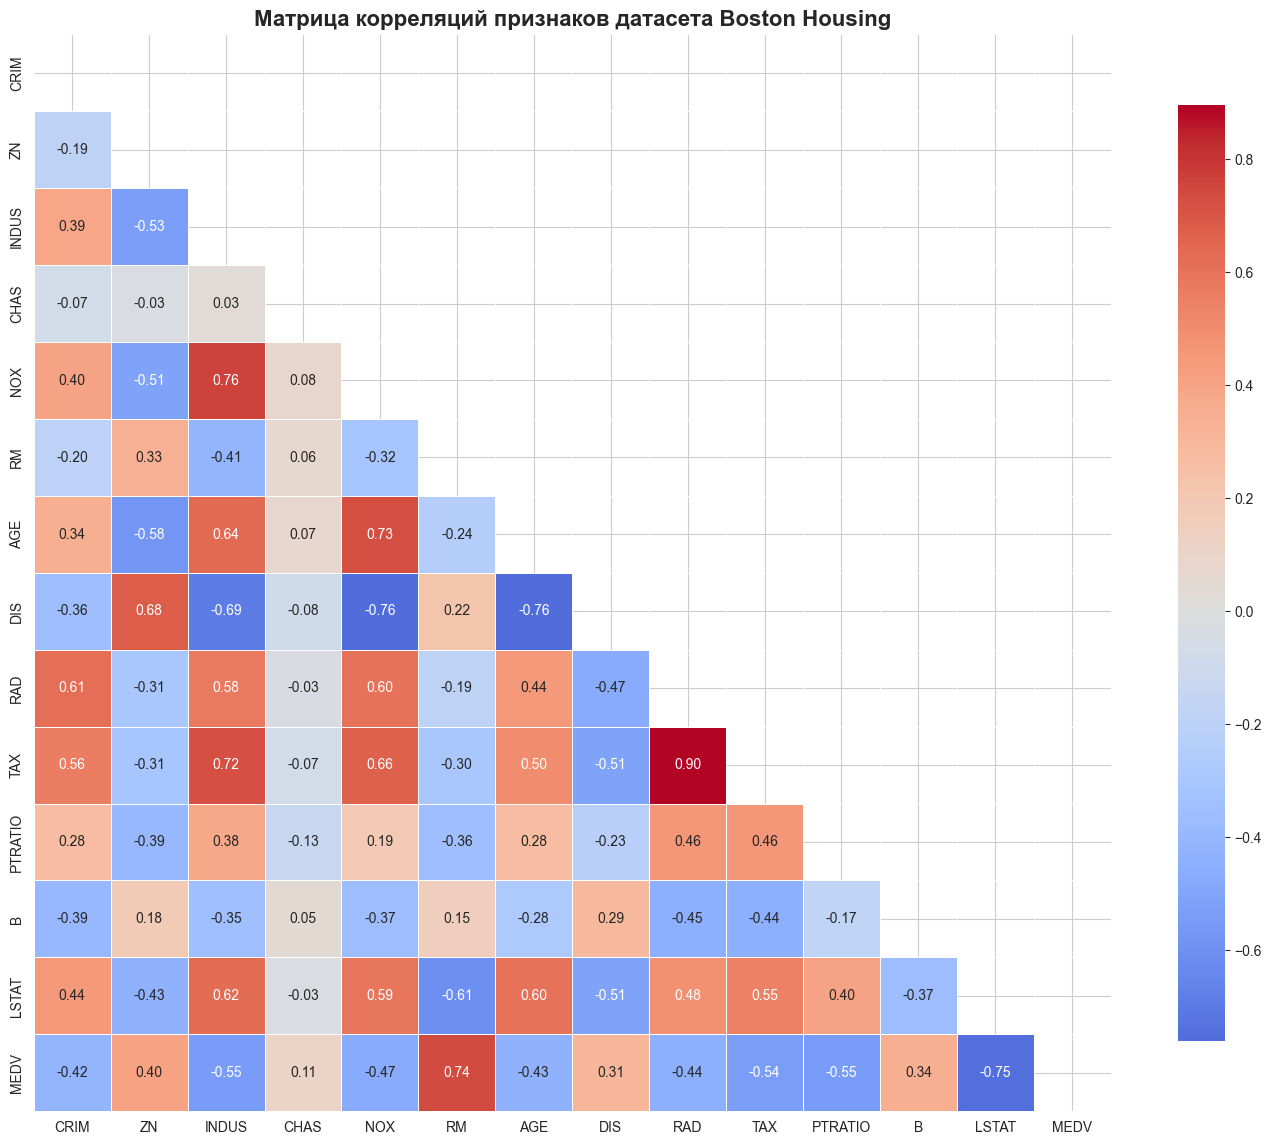

In [6]:
correlation_matrix = df.corr(method='pearson')

# Создаём маску для верхнего треугольника
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title('Матрица корреляций признаков датасета Boston Housing', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
corr_pairs = []

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Признак 1': correlation_matrix.columns[i],
            'Признак 2': correlation_matrix.columns[j],
            'Корреляция': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df = corr_df.sort_values('Корреляция', key=abs, ascending=False)

print("ТОП-10 наиболее сильных корреляций (по модулю):")
corr_df.head(10)

ТОП-10 наиболее сильных корреляций (по модулю):


,Признак 1,Признак 2,Корреляция
76,RAD,TAX,0.896491
26,INDUS,NOX,0.763120
48,NOX,DIS,-0.760426
63,AGE,DIS,-0.759517
90,LSTAT,MEDV,-0.747762
62,RM,MEDV,0.738885
47,NOX,AGE,0.728491
31,INDUS,TAX,0.724661
29,INDUS,DIS,-0.692721
18,ZN,DIS,0.676736


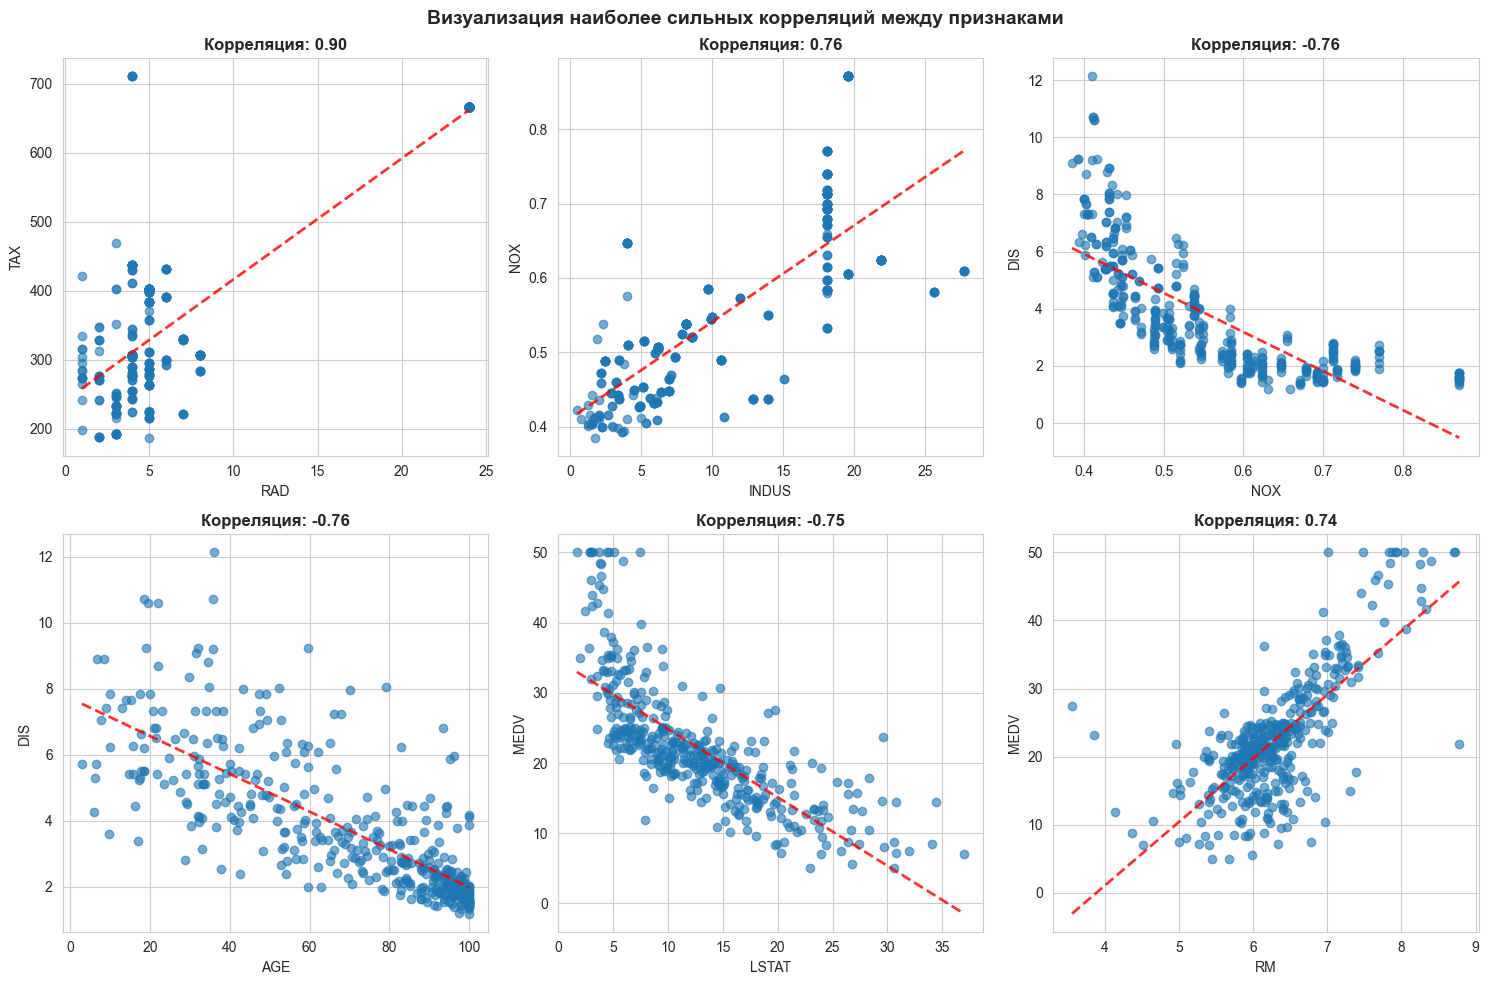

In [8]:
strong_corr_pairs = corr_df.head(6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (_, row) in enumerate(strong_corr_pairs.iterrows()):
    if idx < 6:
        feature1 = row['Признак 1']
        feature2 = row['Признак 2']
        correlation = row['Корреляция']
        
        axes[idx].scatter(df[feature1], df[feature2], alpha=0.6)
        axes[idx].set_xlabel(feature1, fontsize=10)
        axes[idx].set_ylabel(feature2, fontsize=10)
        axes[idx].set_title(f'Корреляция: {correlation:.2f}', fontsize=12, fontweight='bold')
        
        # Линия тренда
        z = np.polyfit(df[feature1], df[feature2], 1)
        p = np.poly1d(z)
        axes[idx].plot(df[feature1].sort_values(), p(df[feature1].sort_values()), 
                      "r--", alpha=0.8, linewidth=2)

plt.suptitle('Визуализация наиболее сильных корреляций между признаками', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

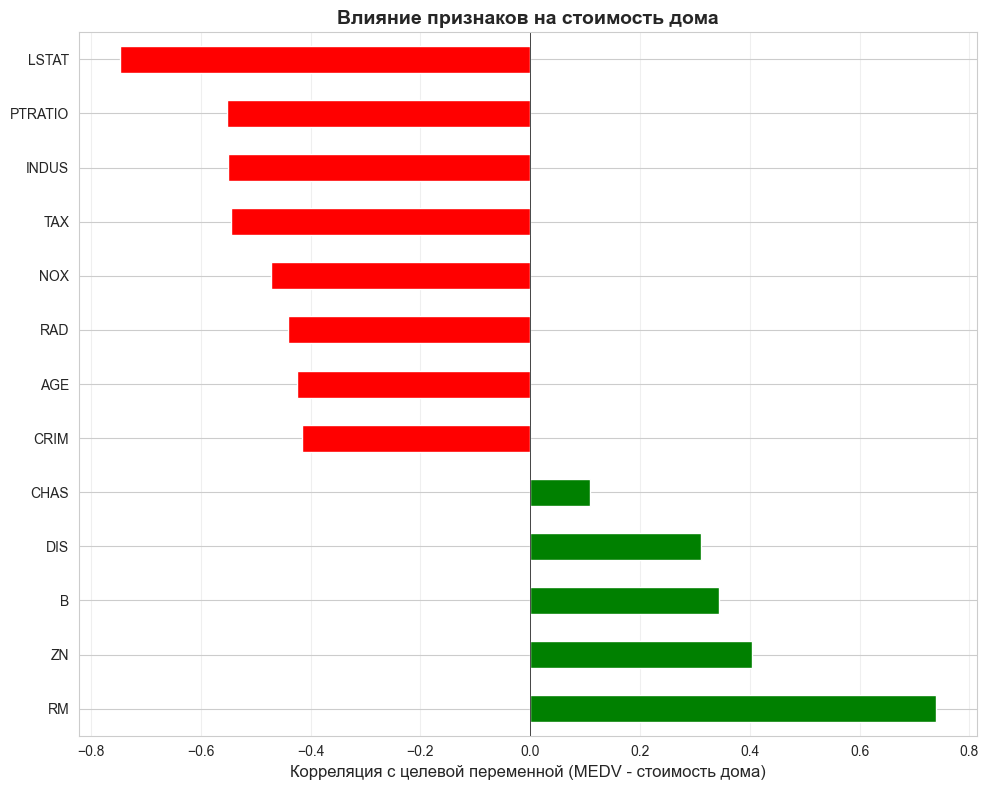


Корреляция признаков с целевой переменной (MEDV):
RM         0.738885
ZN         0.404665
B          0.343714
DIS        0.311382
CHAS       0.109714
CRIM      -0.415833
AGE       -0.425049
RAD       -0.440401
NOX       -0.471905
TAX       -0.544563
INDUS     -0.551450
PTRATIO   -0.552365
LSTAT     -0.747762
Name: MEDV, dtype: float64


In [9]:
target_corr = correlation_matrix['MEDV'].drop('MEDV').sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['red' if x < 0 else 'green' for x in target_corr.values]
target_corr.plot(kind='barh', color=colors)
plt.xlabel('Корреляция с целевой переменной (MEDV - стоимость дома)', fontsize=12)
plt.title('Влияние признаков на стоимость дома', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nКорреляция признаков с целевой переменной (MEDV):")
print(target_corr)

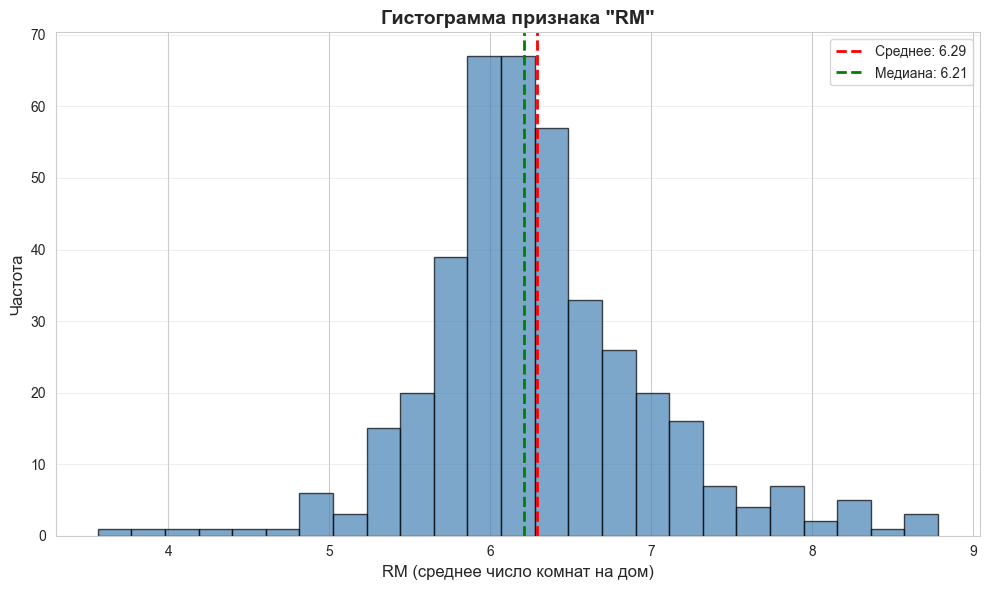


Статистика для признака 'RM':
Среднее: 6.29
Медиана: 6.21
Стандартное отклонение: 0.71
Асимметрия: 0.472


In [10]:
selected_column = 'RM'  # среднее число комнат - один из самых важных признаков

plt.figure(figsize=(10, 6))
plt.hist(df[selected_column], bins=25, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(selected_column + ' (среднее число комнат на дом)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма признака "{selected_column}"', fontsize=14, fontweight='bold')

# Добавляем линии среднего и медианы
plt.axvline(df[selected_column].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Среднее: {df[selected_column].mean():.2f}')
plt.axvline(df[selected_column].median(), color='green', linestyle='--', 
            linewidth=2, label=f'Медиана: {df[selected_column].median():.2f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nСтатистика для признака '{selected_column}':")
print(f"Среднее: {df[selected_column].mean():.2f}")
print(f"Медиана: {df[selected_column].median():.2f}")
print(f"Стандартное отклонение: {df[selected_column].std():.2f}")
print(f"Асимметрия: {df[selected_column].skew():.3f}")

**Выводы:**
1. Данные после удаления пропусков пригодны для построения ML-моделей.
2. На стоимость дома сильнее всего влияют `LSTAT` (-0.74) и `RM` (+0.70).
3. Обнаружена высокая мультиколлинеарность между `TAX` и `RAD` (0.91).
4. Рекомендуемые модели: Random Forest, Gradient Boosting или Ridge-регрессия.
5. Линейная регрессия без предобработки не рекомендуется из-за мультиколлинеарности.
6. Гистограмма `RM` показала распределение, близкое к нормальному (5-7 комнат).